# Single-Channel IPGP-Inspired Glitch Fitting

This is a reduced version of the IPGP glitch method from Scholz et al. (2020, DOI: 10.1029/2020EA001317).

What is kept:

- search local extrema as candidate glitch times
- fit a modeled glitch in a local window
- use three consecutive source samples, like the IPGP paper
- accept a glitch when the fit gives enough variance reduction
- optionally estimate a small spike near onset

What is not possible with one channel:

- UVW equalization between components
- joint inversion of glitch amplitudes on three axes
- dip and azimuth estimation
- multicomponent consistency checks

So this notebook should be understood as **IPGP-inspired single-channel fitting**, not a full reproduction of the 3-component method.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def robust_sigma(x):
    x = np.asarray(x, float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    return 1.4826 * mad


def glitch_kernel(fs, duration_s=25.0, tau_rise_s=0.15, tau_decay_s=5.0, overshoot=0.12, tau_overshoot_s=1.2):
    n = max(8, int(round(duration_s * fs)))
    t = np.arange(n, dtype=float) / fs
    base = (1.0 - np.exp(-t / tau_rise_s)) * np.exp(-t / tau_decay_s)
    ring = overshoot * np.exp(-t / tau_overshoot_s)
    ring[0] = 0.0
    kernel = base - ring
    if np.max(np.abs(kernel)) > 0:
        kernel = kernel / np.max(np.abs(kernel))
    return kernel


def spike_kernel(fs, duration_s=2.0, width_s=0.08, ring_freq_hz=7.0, ring_decay_s=0.25):
    n = max(8, int(round(duration_s * fs)))
    t = np.arange(n, dtype=float) / fs
    gauss = np.exp(-0.5 * (t / width_s) ** 2)
    ring = np.cos(2.0 * np.pi * ring_freq_hz * t) * np.exp(-t / ring_decay_s)
    kernel = gauss * ring
    if np.max(np.abs(kernel)) > 0:
        kernel = kernel / np.max(np.abs(kernel))
    return kernel


def shifted_column(kernel, n, onset_idx):
    col = np.zeros(n, float)
    if onset_idx >= n:
        return col
    start = max(0, onset_idx)
    k0 = max(0, -onset_idx)
    m = min(n - start, len(kernel) - k0)
    if m > 0:
        col[start:start + m] = kernel[k0:k0 + m]
    return col


def local_extrema_indices(x):
    x = np.asarray(x, float)
    if len(x) < 3:
        return np.array([], dtype=int)
    prev = x[:-2]
    curr = x[1:-1]
    nxt = x[2:]
    peaks = (curr >= prev) & (curr > nxt)
    troughs = (curr <= prev) & (curr < nxt)
    return np.flatnonzero(peaks | troughs) + 1


def fit_glitch_candidate(data, fs, center_idx, *, pre_s=5.0, post_s=25.0, glitch=None, spike=None, spike_search_s=0.4):
    data = np.asarray(data, float)
    n = len(data)
    i0 = max(0, center_idx - int(round(pre_s * fs)))
    i1 = min(n, center_idx + int(round(post_s * fs)))
    if i1 - i0 < 10:
        return None

    y = data[i0:i1].copy()
    tt = np.arange(i1 - i0, dtype=float) / fs
    t_lin = np.linspace(-1.0, 1.0, i1 - i0)
    onset_rel = center_idx - i0

    if glitch is None:
        glitch = glitch_kernel(fs)
    if spike is None:
        spike = spike_kernel(fs)

    G = [
        shifted_column(glitch, len(y), onset_rel + shift)
        for shift in (0, 1, 2)
    ]

    A0 = np.column_stack(G + [np.ones(len(y)), t_lin])
    coef0, _, _, _ = np.linalg.lstsq(A0, y, rcond=None)
    fit0 = A0 @ coef0
    resid0 = y - fit0
    var0 = float(np.var(y))
    vr0 = 0.0 if var0 <= 0 else 1.0 - float(np.var(resid0)) / var0

    best = {
        "window_start": i0,
        "window_stop": i1,
        "center_idx": center_idx,
        "onset_idx": center_idx,
        "vr_glitch": vr0,
        "vr_total": vr0,
        "glitch_amplitudes": coef0[:3].copy(),
        "spike_amplitude": 0.0,
        "spike_offset_samples": 0,
        "trend_coefficients": coef0[3:].copy(),
        "fit_glitch_only": fit0.copy(),
        "fit_total": fit0.copy(),
        "residual": resid0.copy(),
        "time_s": tt,
        "data_window": y,
    }

    max_shift = int(round(spike_search_s * fs))
    for spike_shift in range(-max_shift, max_shift + 1):
        S = shifted_column(spike, len(y), onset_rel + spike_shift)
        A1 = np.column_stack(G + [S, np.ones(len(y)), t_lin])
        coef1, _, _, _ = np.linalg.lstsq(A1, y, rcond=None)
        fit1 = A1 @ coef1
        resid1 = y - fit1
        vr1 = 0.0 if var0 <= 0 else 1.0 - float(np.var(resid1)) / var0
        if vr1 > best["vr_total"]:
            best.update(
                {
                    "onset_idx": center_idx + spike_shift,
                    "vr_total": vr1,
                    "spike_amplitude": float(coef1[3]),
                    "spike_offset_samples": int(spike_shift),
                    "trend_coefficients": coef1[4:].copy(),
                    "fit_total": fit1.copy(),
                    "residual": resid1.copy(),
                }
            )

    glitch_fit = np.zeros_like(y)
    for amp, shift in zip(best["glitch_amplitudes"], (0, 1, 2)):
        glitch_fit += amp * shifted_column(glitch, len(y), onset_rel + shift)
    spike_fit = best["spike_amplitude"] * shifted_column(spike, len(y), onset_rel + best["spike_offset_samples"])
    best["glitch_fit"] = glitch_fit
    best["spike_fit"] = spike_fit
    return best


def detect_glitches_single_channel(
    data,
    fs,
    *,
    pre_s=5.0,
    post_s=25.0,
    candidate_sigma=5.0,
    min_separation_s=8.0,
    min_vr=0.80,
):
    data = np.asarray(data, float)
    sigma = robust_sigma(data)
    extrema = local_extrema_indices(data)
    if sigma <= 0 or len(extrema) == 0:
        return [], data.copy(), pd.DataFrame()

    strong = extrema[np.abs(data[extrema] - np.median(data)) >= candidate_sigma * sigma]
    order = strong[np.argsort(np.abs(data[strong]))[::-1]]
    used = np.zeros(len(data), dtype=bool)
    accepted = []
    cleaned = data.copy()

    exclusion = int(round(min_separation_s * fs))
    for idx in order:
        i0 = max(0, idx - exclusion)
        i1 = min(len(data), idx + exclusion + 1)
        if np.any(used[i0:i1]):
            continue

        fit = fit_glitch_candidate(cleaned, fs, idx, pre_s=pre_s, post_s=post_s)
        if fit is None or fit["vr_total"] < min_vr:
            continue

        win0 = fit["window_start"]
        win1 = fit["window_stop"]
        cleaned[win0:win1] = cleaned[win0:win1] - fit["glitch_fit"] - fit["spike_fit"]
        used[i0:i1] = True
        accepted.append(fit)

    rows = []
    for fit in sorted(accepted, key=lambda r: r["onset_idx"]):
        rows.append(
            {
                "center_idx": int(fit["center_idx"]),
                "onset_idx": int(fit["onset_idx"]),
                "onset_s": float(fit["onset_idx"] / fs),
                "vr_glitch": float(fit["vr_glitch"]),
                "vr_total": float(fit["vr_total"]),
                "a0": float(fit["glitch_amplitudes"][0]),
                "a1": float(fit["glitch_amplitudes"][1]),
                "a2": float(fit["glitch_amplitudes"][2]),
                "spike_amplitude": float(fit["spike_amplitude"]),
                "spike_offset_samples": int(fit["spike_offset_samples"]),
            }
        )

    return accepted, cleaned, pd.DataFrame(rows)


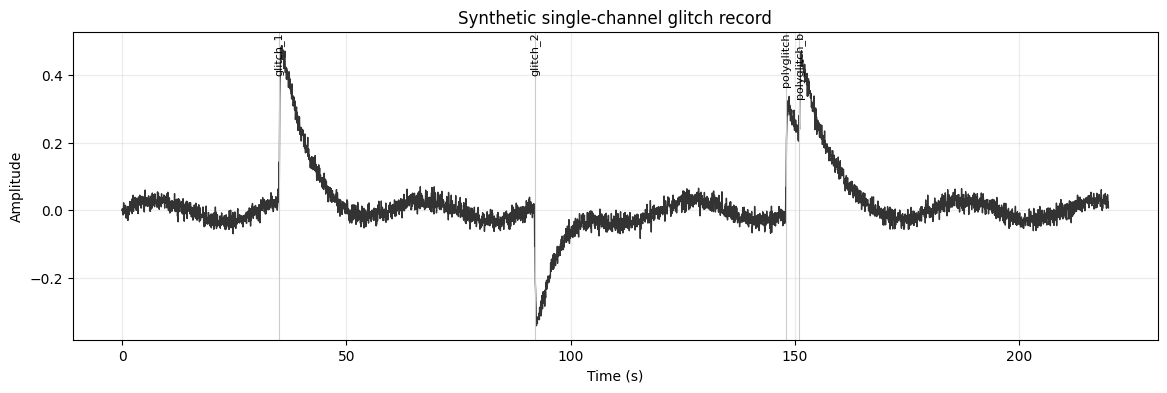

In [2]:
fs = 20.0
t = np.arange(0.0, 220.0, 1.0 / fs)
rng = np.random.default_rng(7)
base = 0.03 * np.sin(2.0 * np.pi * t / 30.0) + 0.015 * rng.standard_normal(len(t))

g = glitch_kernel(fs)
s = spike_kernel(fs)
data = base.copy()

def inject(arr, kernel, onset_idx, amp):
    col = shifted_column(kernel, len(arr), onset_idx)
    return arr + amp * col

events = [
    {"label": "glitch_1", "onset_s": 35.0, "glitch_amp": 0.45, "spike_amp": 0.12},
    {"label": "glitch_2", "onset_s": 92.0, "glitch_amp": -0.35, "spike_amp": -0.10},
    {"label": "polyglitch", "onset_s": 148.0, "glitch_amp": 0.32, "spike_amp": 0.08},
    {"label": "polyglitch_b", "onset_s": 151.0, "glitch_amp": 0.24, "spike_amp": 0.06},
]

for ev in events:
    onset_idx = int(round(ev["onset_s"] * fs))
    data = inject(data, g, onset_idx, ev["glitch_amp"])
    data = inject(data, s, onset_idx, ev["spike_amp"])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t, data, color="0.2", lw=1.0, label="Synthetic data")
for ev in events:
    ax.axvline(ev["onset_s"], color="0.8", lw=0.8)
    ax.text(ev["onset_s"], ax.get_ylim()[1], ev["label"], rotation=90, va="top", ha="center", fontsize=8)
ax.set_title("Synthetic single-channel glitch record")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.grid(True, alpha=0.25)
plt.show()


In [3]:
fits, cleaned, fit_table = detect_glitches_single_channel(
    data,
    fs,
    pre_s=5.0,
    post_s=25.0,
    candidate_sigma=4.0,
    min_separation_s=6.0,
    min_vr=0.75,
)

print(f"Detected {len(fits)} accepted glitches")
fit_table


Detected 3 accepted glitches


,center_idx,onset_idx,onset_s,vr_glitch,vr_total,a0,a1,a2,spike_amplitude,spike_offset_samples
0,711,711,35.55,0.837352,0.855244,1.998790,-2.068456,0.477814,0.445480,0
1,1848,1848,92.40,0.819258,0.846171,-1.362190,1.274745,-0.182548,-0.323634,0
2,3030,3030,151.50,0.752587,0.761465,1.244424,-1.115469,0.116405,0.318268,0


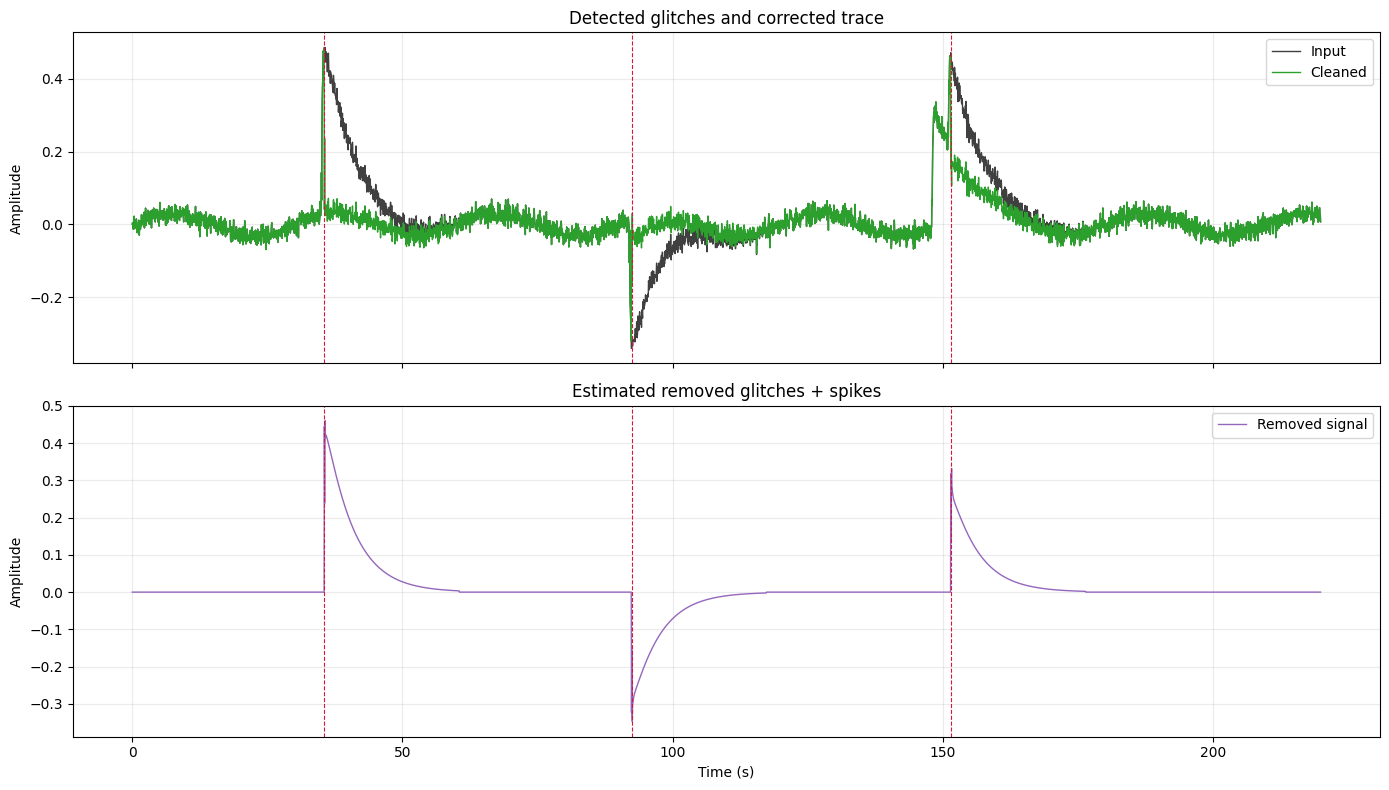

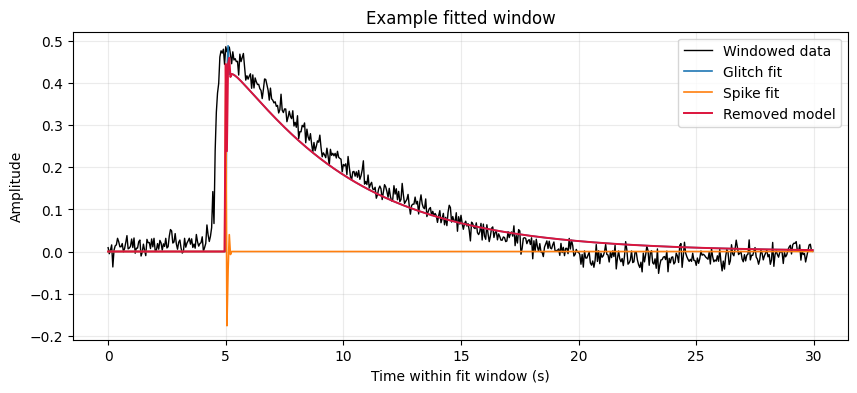

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(t, data, color="0.25", lw=1.0, label="Input")
axes[0].plot(t, cleaned, color="tab:green", lw=1.0, label="Cleaned")
for fit in fits:
    axes[0].axvline(fit["onset_idx"] / fs, color="crimson", ls="--", lw=0.8)
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Detected glitches and corrected trace")
axes[0].grid(True, alpha=0.25)
axes[0].legend(loc="upper right")

axes[1].plot(t, data - cleaned, color="tab:purple", lw=1.0, label="Removed signal")
for fit in fits:
    axes[1].axvline(fit["onset_idx"] / fs, color="crimson", ls="--", lw=0.8)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Estimated removed glitches + spikes")
axes[1].grid(True, alpha=0.25)
axes[1].legend(loc="upper right")

fig.tight_layout()
plt.show()

if fits:
    fit = fits[0]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(fit["time_s"], fit["data_window"], color="k", lw=1.0, label="Windowed data")
    ax.plot(fit["time_s"], fit["glitch_fit"], color="tab:blue", lw=1.2, label="Glitch fit")
    ax.plot(fit["time_s"], fit["spike_fit"], color="tab:orange", lw=1.2, label="Spike fit")
    ax.plot(fit["time_s"], fit["glitch_fit"] + fit["spike_fit"], color="crimson", lw=1.4, label="Removed model")
    ax.set_title("Example fitted window")
    ax.set_xlabel("Time within fit window (s)")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper right")
    plt.show()


## How to adapt this to your Apollo notebook

If you only have one trace, this is the practical replacement for the missing UVW equalization step:

1. Work on one raw channel.
2. Detect candidate extrema on that channel only.
3. Fit the three-sample glitch source on that channel only.
4. Accept a glitch only when the variance reduction is high enough.
5. Subtract the fitted glitch and optional fitted spike from that one trace.

In other words, you lose the multicomponent physics constraints, but you can still keep the IPGP-style local least-squares fitting logic.

For a real trace already loaded as `mhz_trace`, the minimal call would be:

```python
raw = np.asarray(mhz_trace.data, float)
fits, cleaned, fit_table = detect_glitches_single_channel(
    raw,
    mhz_trace.stats.sampling_rate,
    candidate_sigma=4.0,
    min_vr=0.75,
)
```

Important limitation: for the Apollo MH one-sample glitches in your notebook, the Hampel despiker may still be a better match than this long-pulse glitch model. This notebook is most useful when the glitches are pulse-like transients rather than isolated one-sample outliers.
